Accuracy: 0.9772777248405776
AUC Score: 0.9241132048644558
Precision: 0.37219101123595505
Recall: 0.6050228310502284
F1 Score: 0.4608695652173913


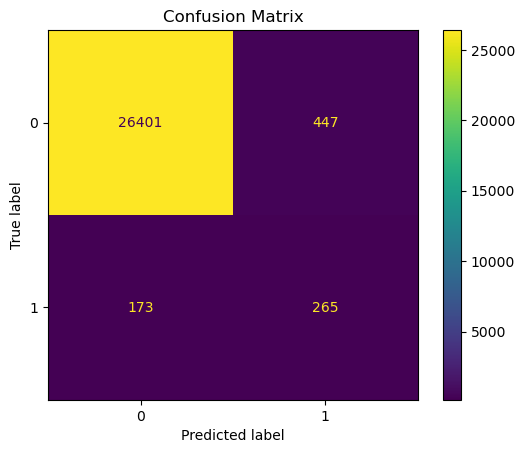

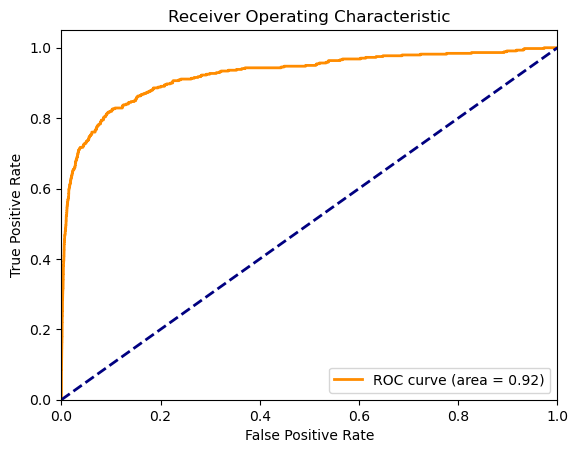

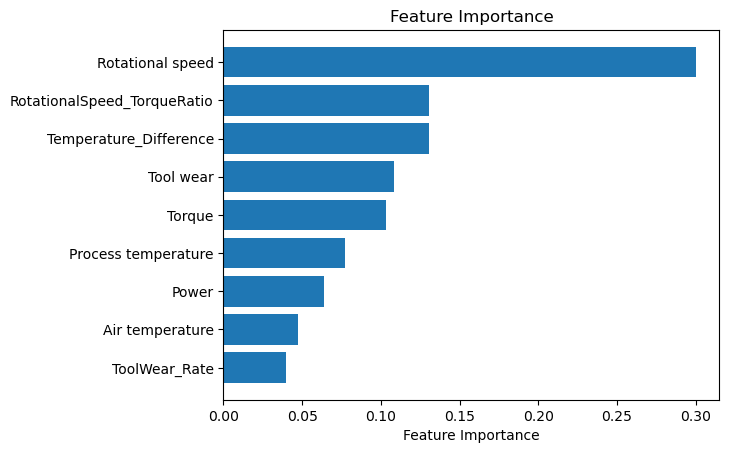

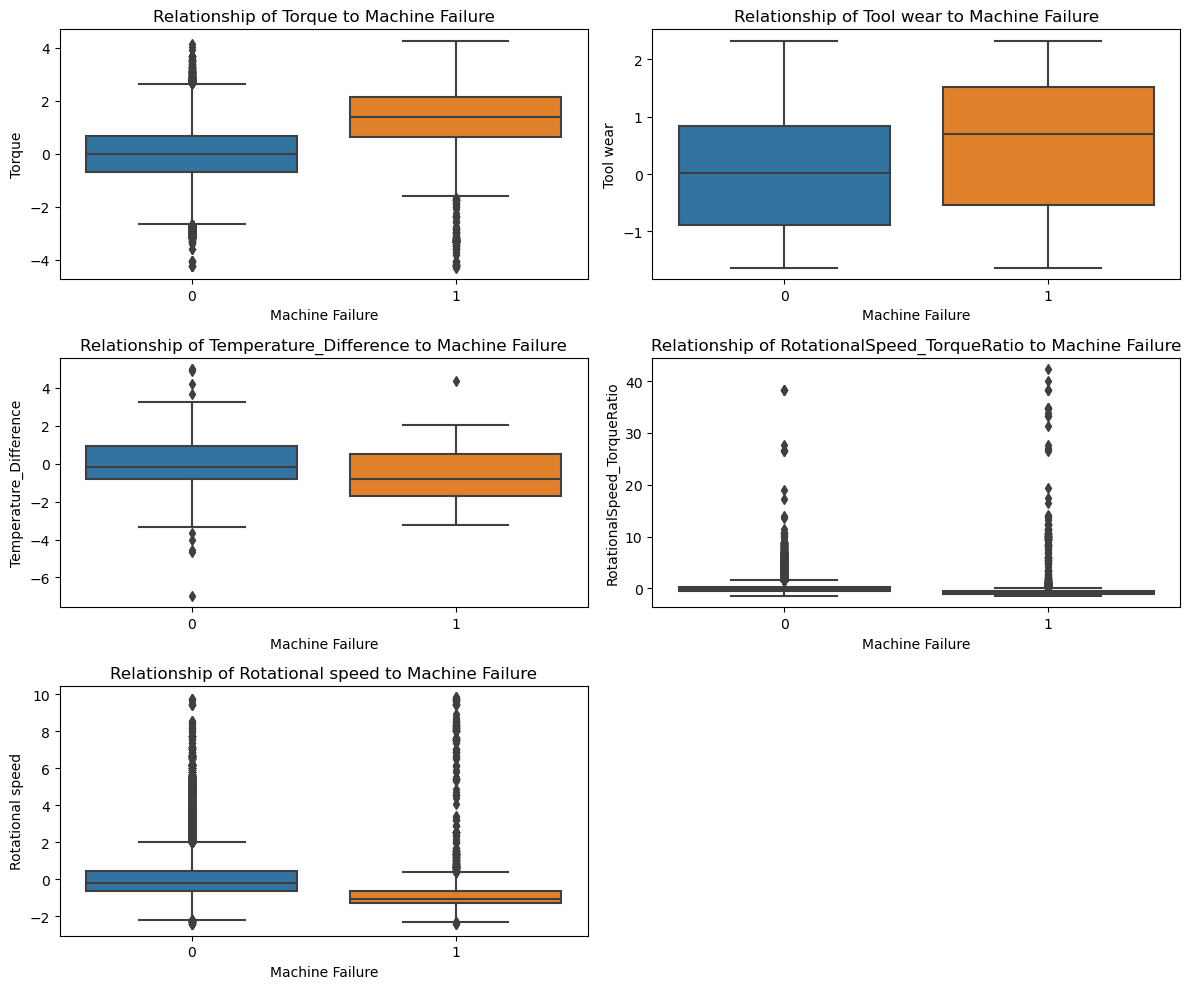

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score

# 데이터 로드
data = pd.read_csv('/Users/kimminsung/desktop/new.csv')


# 목적 변수 설정
target = 'Machine_failure'
X = data.drop(target, axis=1)
y = data[target]

# 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# SMOTE 오버샘플링 적용
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# 하이퍼파라미터 조정을 위한 그리드 설정 및 그리드 서치 초기화
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 0.9, 1.0]
}
grid_search = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss'), param_grid, cv=3, scoring='roc_auc')
grid_search.fit(X_resampled, y_resampled)

# 최적의 모델 선택
model = grid_search.best_estimator_

# 예측
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(f'AUC Score: {auc_score}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

# ROC 곡선
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# 피처 중요도 시각화
feature_importances = model.feature_importances_
sorted_idx = feature_importances.argsort()
plt.barh(X.columns[sorted_idx], feature_importances[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance')
plt.show()

# 피처 중요도가 높은 상위 5개 특성 추출
top_features_indices = feature_importances.argsort()[-5:]  # 가장 중요한 5개 특성의 인덱스
top_features = X.columns[top_features_indices]  # 가장 중요한 5개 특성의 이름

# 상위 5개 특성과 Machine_failure의 관계 시각화
plt.figure(figsize=(12, 10))
for i, feature in enumerate(top_features):
    plt.subplot(3, 2, i + 1)  # 3행 2열의 서브플롯 준비
    sns.boxplot(x=y, y=X_scaled[:, top_features_indices[i]], data=pd.DataFrame(X_scaled, columns=X.columns))
    plt.title(f'Relationship of {feature} to Machine Failure')
    plt.xlabel('Machine Failure')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()



/Users/kimminsung/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/kimminsung/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/kimminsung/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/kimminsung/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

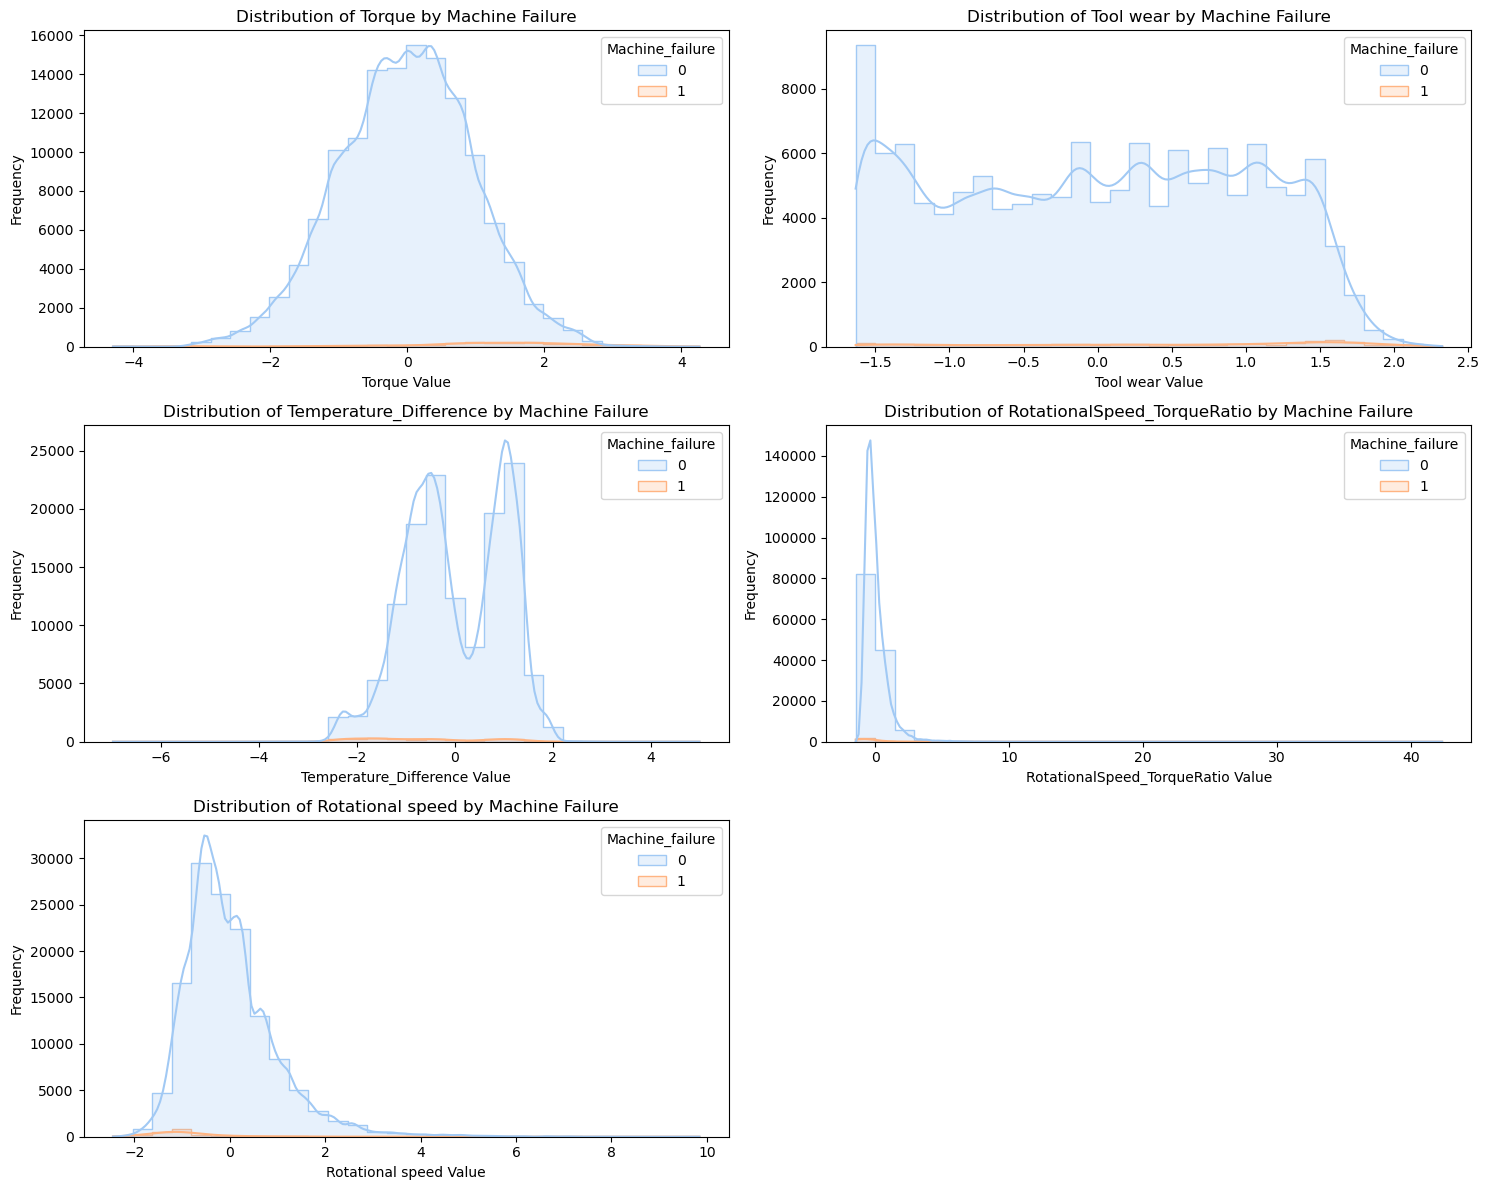

In [14]:
# 상위 5개 특성에 대한 히스토그램
plt.figure(figsize=(15, 12))
for i, feature in enumerate(top_features):
    plt.subplot(3, 2, i + 1)  # 3행 2열의 서브플롯 준비
    sns.histplot(data=pd.DataFrame(X_scaled, columns=X.columns), x=feature, hue=y, kde=True, element='step', palette='pastel', bins=30)
    plt.title(f'Distribution of {feature} by Machine Failure')
    plt.xlabel(f'{feature} Value')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


/Users/kimminsung/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/kimminsung/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/kimminsung/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/kimminsung/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

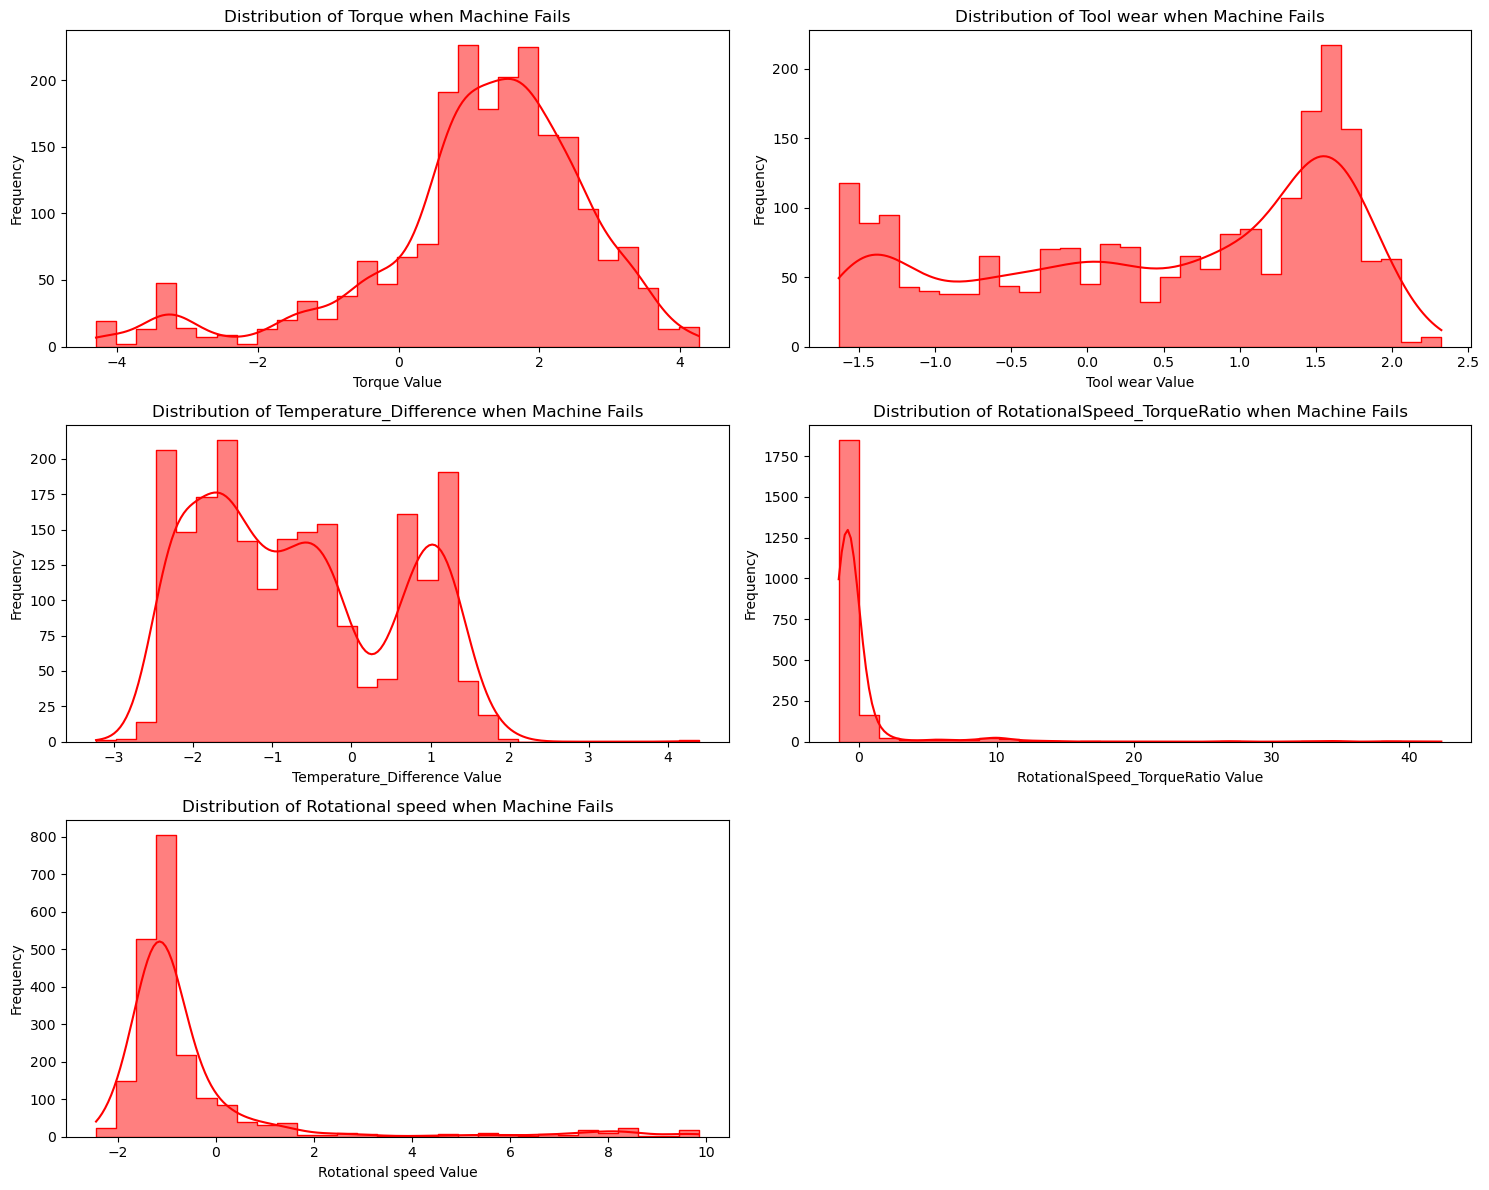

In [15]:
# 고장이 난 경우의 상위 5개 특성 분포
plt.figure(figsize=(15, 12))
failed_data = pd.DataFrame(X_scaled[y == 1], columns=X.columns)  # 고장 난 데이터만 추출
for i, feature in enumerate(top_features):
    plt.subplot(3, 2, i + 1)  # 3행 2열의 서브플롯 준비
    sns.histplot(failed_data, x=feature, kde=True, color='red', element='step', bins=30)
    plt.title(f'Distribution of {feature} when Machine Fails')
    plt.xlabel(f'{feature} Value')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


Accuracy: 0.8697674418604651
AUC Score: 0.9335036005552664
Precision: 0.8756345177664975
Recall: 0.8455882352941176
F1 Score: 0.8603491271820448


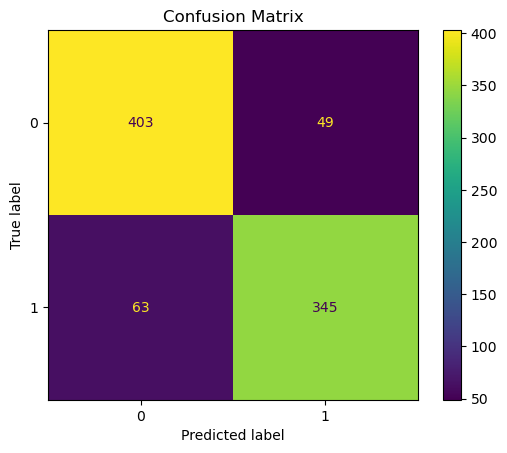

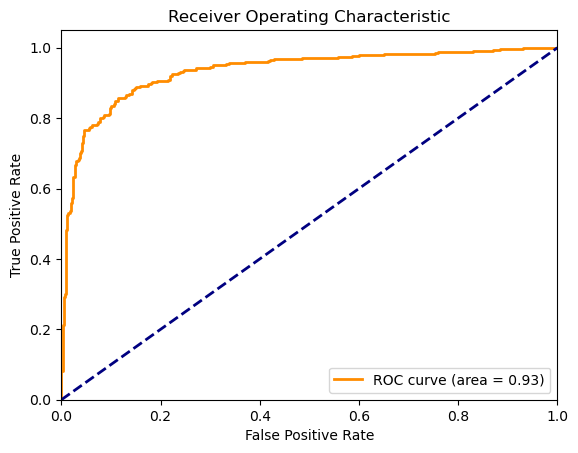

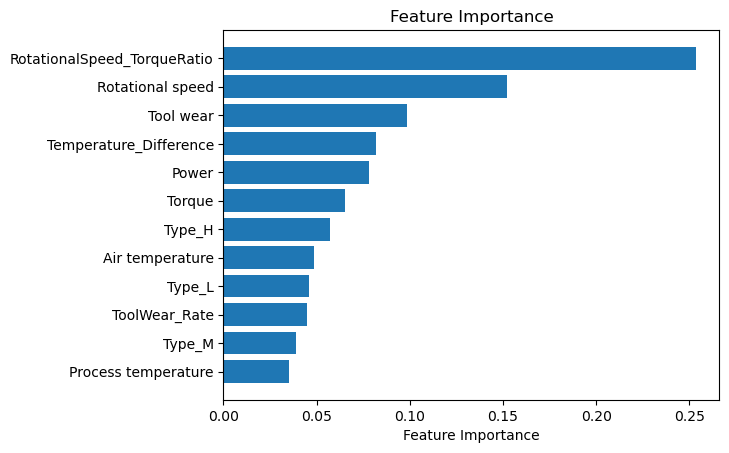

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score

# 데이터 로드
data = pd.read_csv('/Users/kimminsung/desktop/new.csv')

# 범주형 데이터 원-핫 인코딩
data = pd.get_dummies(data, columns=['Type'])

# 목적 변수 설정
target = 'Machine_failure'
X = data.drop(target, axis=1)
y = data[target]

# 클래스별 샘플 수 조정
failure_count = y.sum()
non_failure = y == 0
failure = y == 1

# 고장이 발생한 경우와 발생하지 않은 경우를 동일하게 샘플링
balanced_non_failure = data[non_failure].sample(failure_count, random_state=42)
balanced_failure = data[failure]

# 새로운 데이터프레임 생성
balanced_data = pd.concat([balanced_non_failure, balanced_failure])

# 목적 변수 및 피처 다시 설정
X_balanced = balanced_data.drop(target, axis=1)
y_balanced = balanced_data[target]

# 데이터 정규화
scaler = StandardScaler()
X_balanced_scaled = scaler.fit_transform(X_balanced)

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X_balanced_scaled, y_balanced, test_size=0.2, random_state=42)

# 모델 초기화 및 학습
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(f'AUC Score: {auc_score}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

# ROC 곡선
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# 피처 중요도 시각화
feature_importances = model.feature_importances_
sorted_idx = feature_importances.argsort()
plt.barh(X.columns[sorted_idx], feature_importances[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance')
plt.show()


Accuracy: 0.8826137946199516
AUC Score: 0.9342925724933466
Precision: 0.1080238162744542
Recall: 0.8698630136986302
F1 Score: 0.19218158890290035


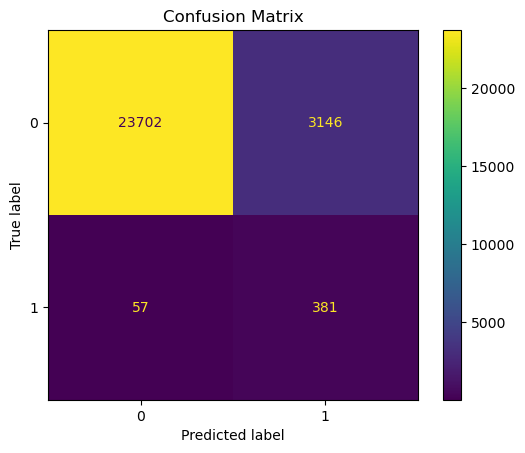

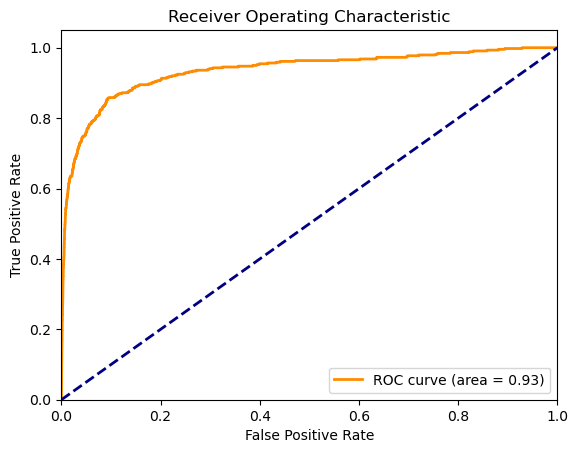

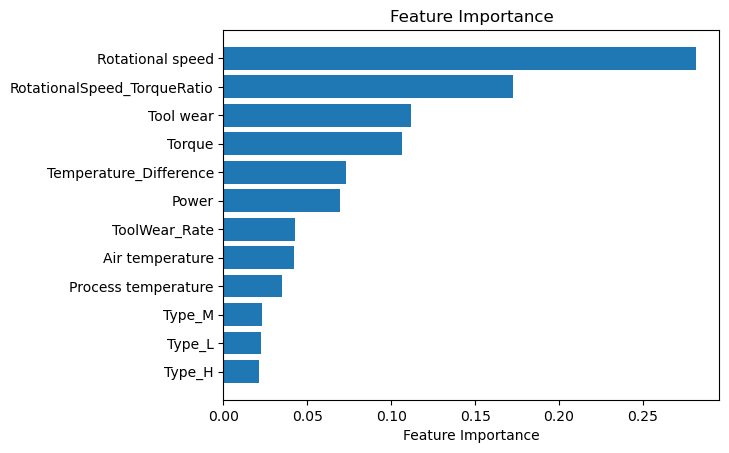

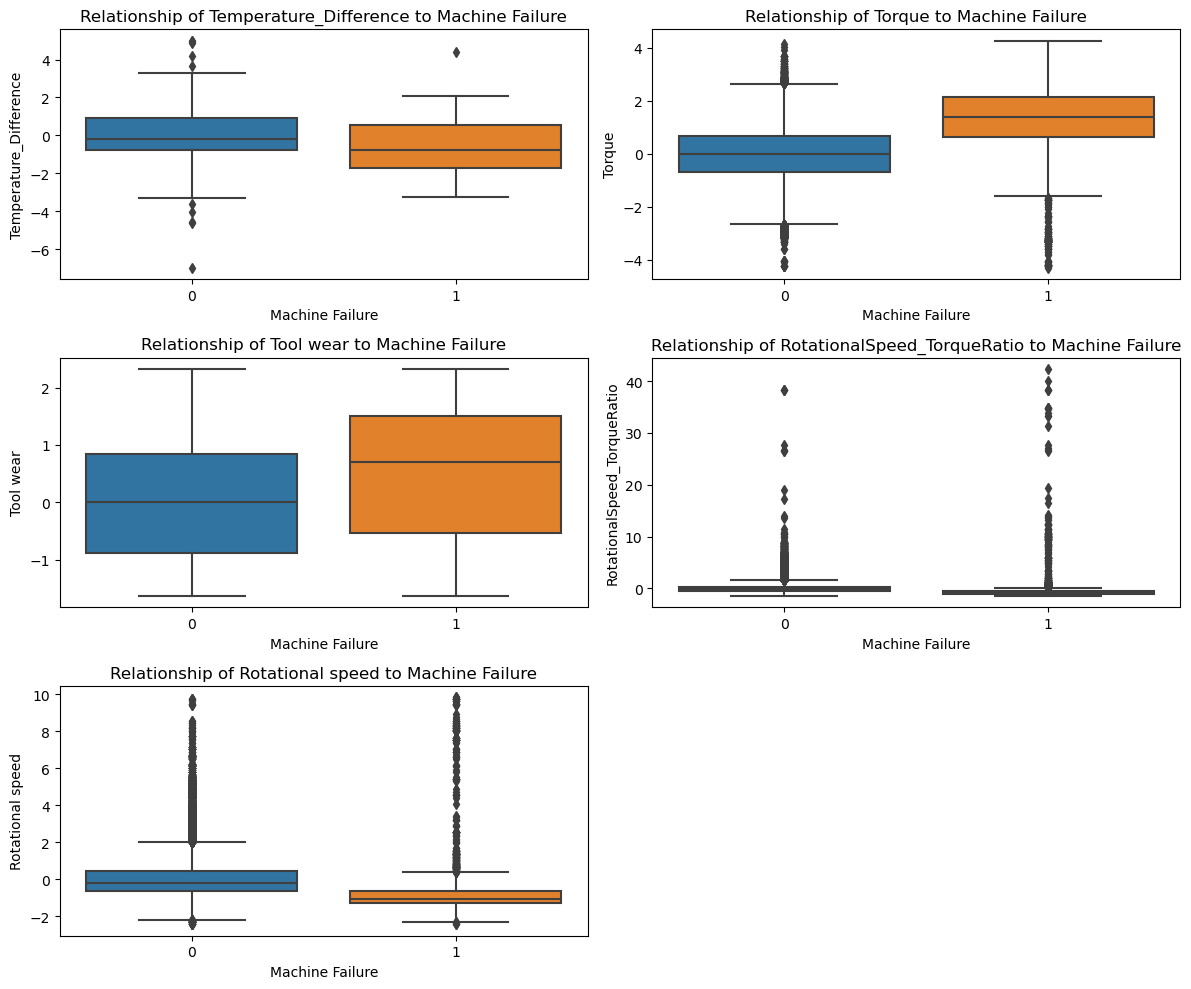

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler  # 언더샘플링을 위한 라이브러리
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score
import seaborn as sns

# 데이터 로드
data = pd.read_csv('/Users/kimminsung/desktop/new.csv')

# 범주형 데이터 원-핫 인코딩
data = pd.get_dummies(data, columns=['Type'])

# 목적 변수 설정
target = 'Machine_failure'
X = data.drop(target, axis=1)
y = data[target]

# 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 언더샘플링 적용
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X_train, y_train)

# 하이퍼파라미터 조정을 위한 그리드 설정 및 그리드 서치 초기화
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 0.9, 1.0]
}
grid_search = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss'), param_grid, cv=3, scoring='roc_auc')
grid_search.fit(X_resampled, y_resampled)

# 최적의 모델 선택
model = grid_search.best_estimator_

# 예측
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(f'AUC Score: {auc_score}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

# ROC 곡선
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# 피처 중요도 시각화
feature_importances = model.feature_importances_
sorted_idx = feature_importances.argsort()
plt.barh(X.columns[sorted_idx], feature_importances[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance')
plt.show()

# 피처 중요도가 높은 상위 5개 특성 추출
top_features_indices = feature_importances.argsort()[-5:]  # 가장 중요한 5개 특성의 인덱스
top_features = X.columns[top_features_indices]  # 가장 중요한 5개 특성의 이름

# 상위 5개 특성과 Machine_failure의 관계 시각화
plt.figure(figsize=(12, 10))
for i, feature in enumerate(top_features):
    plt.subplot(3, 2, i + 1)  # 3행 2열의 서브플롯 준비
    sns.boxplot(x=y, y=X_scaled[:, top_features_indices[i]], data=pd.DataFrame(X_scaled, columns=X.columns))
    plt.title(f'Relationship of {feature} to Machine Failure')
    plt.xlabel('Machine Failure')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()


Accuracy: 0.9837279190793814
AUC Score: 0.9241132048644558
Precision: 0.4929906542056075
Recall: 0.4817351598173516
F1 Score: 0.48729792147806006


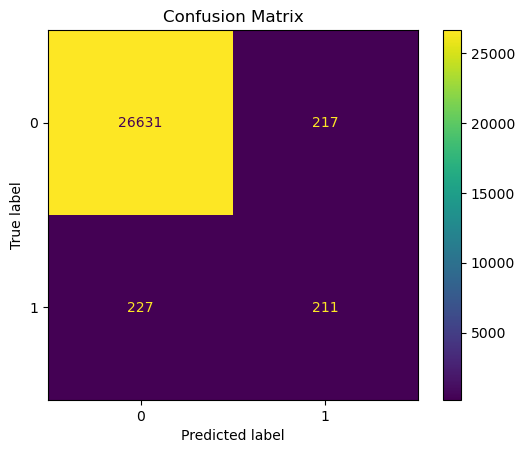

In [17]:
# 예측 확률 계산
y_pred_proba = model.predict_proba(X_test)[:, 1]

# AUC 점수 계산
auc_score = roc_auc_score(y_test, y_pred_proba)  # 이 부분을 추가

# 임계값을 0.7로 설정하여 예측
threshold = 0.7
y_pred = (y_pred_proba >= threshold).astype(int)

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(f'AUC Score: {auc_score}')  # 이제 정의된 auc_score를 사용
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()